🧠 Energy consumption analysis Jupyter notebook

📦 Install required packages

In [1]:
!pip install nltk sentence-transformers torch PyMuPDF
!pip install pandas
!pip install matplotlib
!pip install -U kaleido
!pip install plotly

📚 Import libraries

In [2]:
import nltk
import torch
import fitz  # PyMuPDF
import pandas as pd
from pathlib import Path
from sentence_transformers import SentenceTransformer, util
from nltk.tokenize import sent_tokenize
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio

nltk.download('punkt')
nltk.download('punkt_tab')


/home/bogdan/Desktop/Execo-rep-pkg/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to /home/bogdan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/bogdan/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

🏷️ Define energy consumption codebook

In [3]:
codebook = [
    {"code": "Model Size", "description": "The number of parameters in the LLM, which directly impacts the computational cost of training and inference."},
    {"code": "Inference Workload", "description": "The computational demand of running the model during inference, affected by prompt length, batch size, and token generation."},
    {"code": "Hardware Efficiency", "description": "The type and efficiency of the hardware (GPU, CPU, TPU) used to run the model, influencing energy draw per operation."},
    {"code": "System Configuration", "description": "The software stack and runtime (e.g., PyTorch, ONNX) used and backend settings that affect energy consumption during execution."},
    {"code": "Model Optimization Techniques", "description": "Approaches like quantization, pruning, and early exit that reduce computation and thus energy use while maintaining performance."},
    {"code": "Deployment Environment", "description": "The location and infrastructure of the models deployment (e.g., cloud vs. on-prem, cooling efficiency, power source) influencing total energy usage."},
    {"code": "Duration of Use", "description": "The total operational time a model is active and serving requests, longer durations increase cumulative energy consumption."}
]

code_descriptions = [code['description'] for code in codebook]

📄 Load and extract text from all PDFs in the folder

In [4]:
def extract_text_from_pdf(pdf_path):
    text = ""
    with fitz.open(pdf_path) as doc:
        for page in doc:
            text += page.get_text() + ""
    return text

# Set path to your folder of PDFs
pdf_folder = Path("./Papers/")  # Put your PDFs here
pdf_files = list(pdf_folder.glob("*.pdf"))
print(f"Found {len(pdf_files)} PDF files.")

Found 46 PDF files.


🤖 Load model

In [5]:
model = SentenceTransformer('all-mpnet-base-v2')

🧠 Process each PDF

In [6]:
results = []
threshold = 0.5

code_embeddings = model.encode(code_descriptions, convert_to_tensor=True)

for pdf_path in pdf_files:
    text = extract_text_from_pdf(pdf_path)
    segments = sent_tokenize(text)
    text_embeddings = model.encode(segments, convert_to_tensor=True)
    
    for i, segment in enumerate(segments):
        sim_scores = util.cos_sim(text_embeddings[i], code_embeddings)[0]
        for score, code_idx in zip(sim_scores, range(len(codebook))):
            if score >= threshold:
                results.append({
                    "File": pdf_path.name,
                    "Text Segment": segment,
                    "Code": codebook[code_idx]['code'],
                    "Score": float(score)
                })

print(f"✅ Done processing {len(pdf_files)} files. Total coded segments: {len(results)}")

✅ Done processing 46 files. Total coded segments: 3390


💾 Export to CSV

In [7]:
df = pd.DataFrame(results)
df.to_csv("./CSVs/coded_output_from_pdfs_energy_consumption.csv", index=False, encoding='utf-8')
df.head()

,File,Text Segment,Code,Score
0,3593434.3594236.pdf,These models are usually\ntrained on large dat...,Inference Workload,0.500022
1,3593434.3594236.pdf,The\nselection of a tokenization method can ha...,Inference Workload,0.610606
2,3593434.3594236.pdf,The results indicate that the choice\nof token...,Inference Workload,0.589478
3,3593434.3594236.pdf,It could signif-\nicantly impact the model’s p...,Inference Workload,0.587219
4,3593434.3594236.pdf,Several unknown tokens could falsely boost the...,Inference Workload,0.622460


💾 Aggregate frequency and document count per code

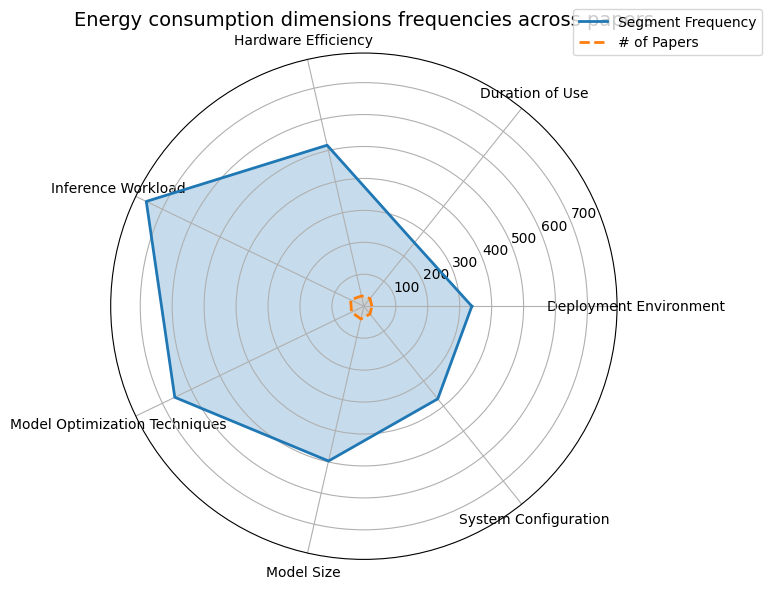

In [8]:
code_stats = df.groupby("Code").agg({
    "Text Segment": "count",
    "File": pd.Series.nunique
}).rename(columns={
    "Text Segment": "Frequency",
    "File": "Documents"
}).reset_index()

labels = code_stats["Code"].tolist()
freq = code_stats["Frequency"].tolist()
docs = code_stats["Documents"].tolist()
# Radar setup
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
freq += freq[:1]
docs += docs[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 6), subplot_kw=dict(polar=True))
ax.plot(angles, freq, label="Segment Frequency", linewidth=2)
ax.fill(angles, freq, alpha=0.25)

ax.plot(angles, docs, label="# of Papers", linestyle='dashed', linewidth=2)
ax.fill(angles, docs, alpha=0.1)

ax.set_thetagrids(np.degrees(angles[:-1]), labels)
plt.title("Energy consumption dimensions frequencies across papers", fontsize=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()

# Show plot
plt.show()

Radar plot with the curated CSV file through ChatGPT

In [3]:
# Load data
data = pd.read_csv("./CSVs/curated_codes_energy_consumption.csv")
label_counts = data['Code'].value_counts()

# Create bar plot (occurrences of codes)
fig = go.Figure(data=go.Bar(
    x=label_counts.index,
    y=label_counts.values,
    marker_color='blue'
))

fig.update_layout(
    xaxis_title='Codes',
    yaxis_title='Number of Occurrences',
    showlegend=False
)

# Export as PDF
pio.write_image(fig, "./Figures/bar_plot_codes_occurances_energy_consumption.pdf", format="pdf")



In [4]:
# Load data
data = pd.read_csv("./CSVs/curated_codes_energy_consumption.csv")

# Count the number of unique papers per code
papers_per_code = data.groupby('Code')['File'].nunique().sort_values(ascending=False)

# Create bar plot (number of papers per code)
fig = go.Figure(data=go.Bar(
    x=papers_per_code.index,
    y=papers_per_code.values,
    marker_color='blue'
))

fig.update_layout(
    xaxis_title='Code',
    yaxis_title='Number of Papers',
    xaxis_tickangle=-45,
    showlegend=False
)

# Export as PDF
pio.write_image(fig, "./Figures/bar_plot_papers_per_code_energy_consumption.pdf", format="pdf")